# 📡 QoSBuddy — DSO1.3 · Network Performance Benchmarking
**Member 5 | PingWin – ESPRIT**

## ⚙️ Setup

In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn shap

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, seaborn as sns, warnings, os
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
%matplotlib inline

DATA_PATH  = r"C:/Users/Mega-PC/Downloads/5g_dataset2.csv"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Core QoS features used for scoring
QOS_FEATURES = ["sinr_dl_db","throughput_mbps","delay_ms","jitter_ms","packet_loss_ratio","retransmissions"]

# ── IMPORTANT: proxy features used for ML (not for rule labeling) ─────────────
# The rule label is a deterministic function of throughput, delay, packet_loss.
# Feeding those same columns as ML features gives 100% accuracy trivially.
# We use RADIO/UPSTREAM features that PREDICT performance without defining it.
PROXY_FEATURES = ["sinr_dl_db","jitter_ms","retransmissions","prb_utilization","cqi","mcs_dl"]

QOS_WEIGHTS = dict(throughput=0.40, sinr=0.20, delay=0.15, jitter=0.15, packet_loss=0.10)
PALETTE     = {"GOOD":"#2ecc71","MEDIUM":"#f39c12","POOR":"#e74c3c"}
print("Ready ✅")
print(f"Rule features (label only): throughput_mbps, delay_ms, packet_loss_ratio")
print(f"ML features  (proxy only) : {PROXY_FEATURES}")

Ready ✅
Rule features (label only): throughput_mbps, delay_ms, packet_loss_ratio
ML features  (proxy only) : ['sinr_dl_db', 'jitter_ms', 'retransmissions', 'prb_utilization', 'cqi', 'mcs_dl']


---
## Phase 1 — Load & Explore

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
missing = df.isnull().sum(); missing = missing[missing>0]
print("Missing:", missing if not missing.empty else "None ✓")
df.head()

Shape: (32525, 14)
Missing: None ✓


,timestamp,ue_id,sinr_dl_db,mcs_dl,throughput_mbps,delay_ms,jitter_ms,packet_loss_ratio,prb_utilization,retransmissions,cqi,load_level,mobility_speed,shadowing_enabled
0,1,1,-20.51350,0,0.058944,268.886,4.16667,0.970,4,283,0,1,0,0
1,2,1,-5.82407,0,0.481376,135.327,6.69679,0.755,6,1,0,1,0,0
2,3,1,-12.05090,0,0.275072,241.141,25.89800,0.860,3,271,0,1,0,0
3,4,1,-9.74370,0,0.000000,0.000,0.00000,1.000,4,410,0,1,0,0
4,5,1,-7.68551,0,0.324192,133.992,20.00000,0.835,3,339,0,1,0,0


In [4]:
df.describe().round(3)

,timestamp,ue_id,sinr_dl_db,mcs_dl,throughput_mbps,delay_ms,jitter_ms,packet_loss_ratio,prb_utilization,retransmissions,cqi,load_level,mobility_speed,shadowing_enabled
count,32525.000,32525.000,32525.000,32525.000,32525.000,32525.000,32525.000,32525.000,32525.000,32525.000,32525.000,32525.000,32525.000,32525.000
mean,245.948,3.000,5.102,10.854,2.951,135.237,22.765,0.438,3.299,116.017,6.341,1.993,0.496,0.212
std,215.782,1.414,21.928,10.121,2.876,361.450,40.532,0.436,1.874,186.543,5.661,1.106,1.294,0.409
min,1.000,1.000,-42.301,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000
25%,83.000,2.000,-12.064,0.000,0.226,8.153,3.420,0.035,2.000,3.000,0.000,1.000,0.000,0.000
50%,182.000,3.000,6.486,11.000,2.041,30.119,7.249,0.077,3.000,8.000,7.000,2.000,0.000,0.000
75%,338.000,4.000,17.907,20.000,5.458,69.560,27.292,0.945,4.000,193.000,11.000,2.000,0.000,0.000
max,932.000,5.000,90.978,28.000,9.500,9499.980,999.972,1.000,12.000,1000.000,15.000,5.000,10.000,1.000


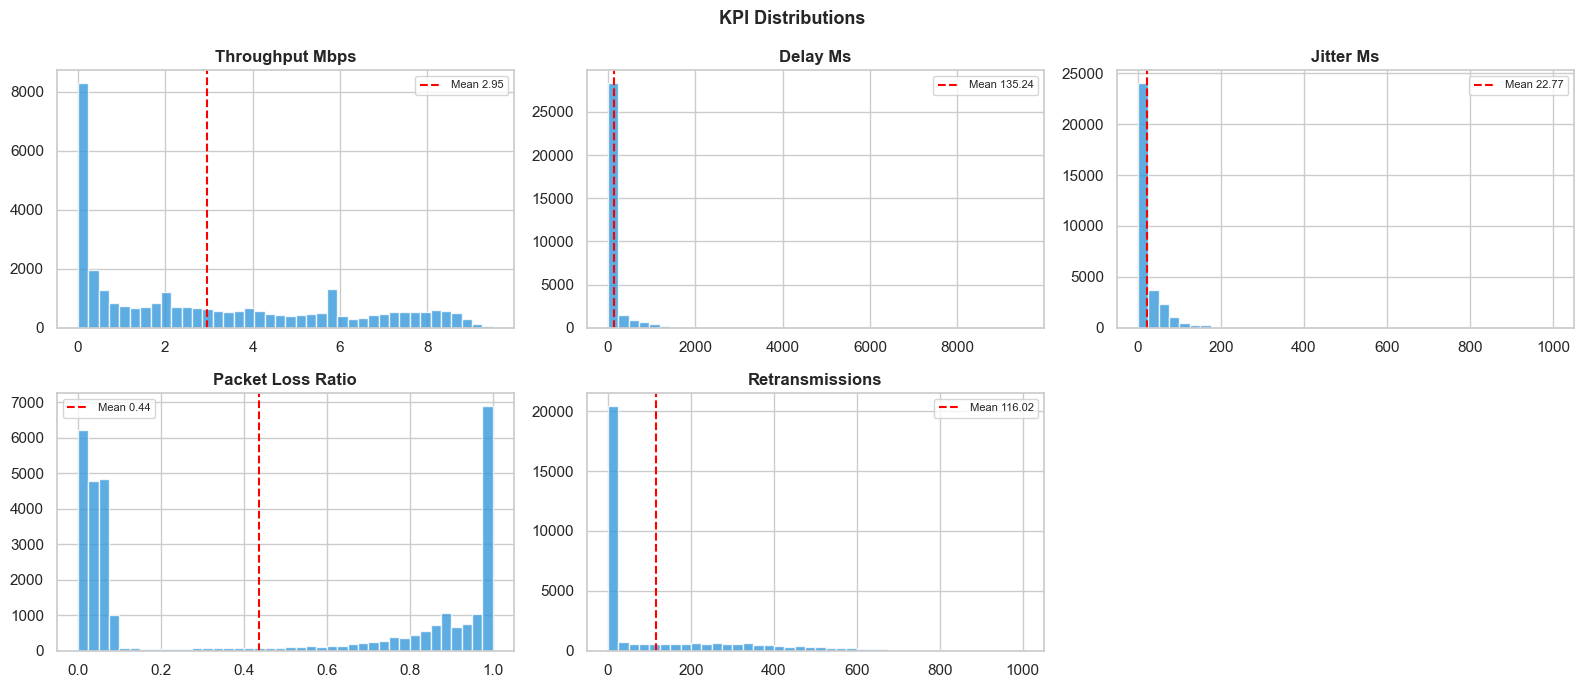

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16,7))
for i, col in enumerate(["throughput_mbps","delay_ms","jitter_ms","packet_loss_ratio","retransmissions"]):
    ax = axes.flatten()[i]
    ax.hist(df[col], bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(df[col].mean(), color="red", linestyle="--", lw=1.5, label=f"Mean {df[col].mean():.2f}")
    ax.set_title(col.replace("_"," ").title(), fontweight="bold"); ax.legend(fontsize=8)
axes.flatten()[-1].set_visible(False)
plt.suptitle("KPI Distributions", fontsize=13, fontweight="bold"); plt.tight_layout(); plt.show()

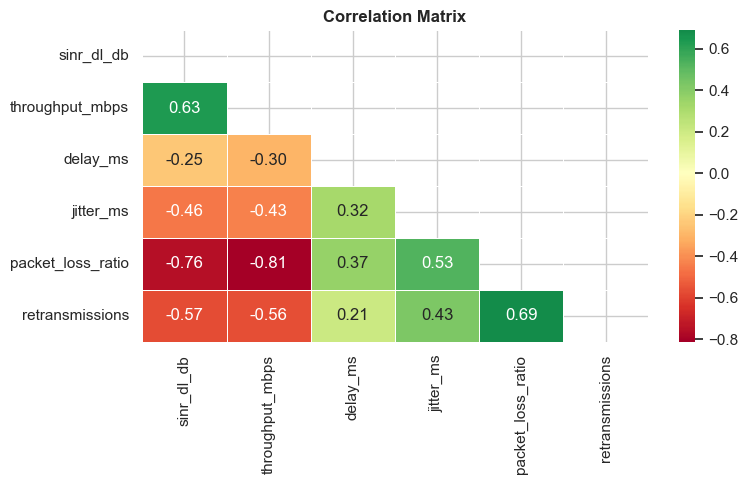

In [6]:
fig, ax = plt.subplots(figsize=(8,5))
corr = df[QOS_FEATURES].corr()
sns.heatmap(corr, mask=np.triu(np.ones_like(corr,dtype=bool)), annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix", fontweight="bold"); plt.tight_layout(); plt.show()

---
## Phase 2 — Preprocessing

In [7]:
df_c = df.copy()
for col in QOS_FEATURES:
    if df_c[col].isnull().any(): df_c[col].fillna(df_c[col].median(), inplace=True)

# Normalise QoS features + proxy features together
ALL_NORM = list(set(QOS_FEATURES + PROXY_FEATURES))
scaler = MinMaxScaler()
df_c[[f"norm_{f}" for f in ALL_NORM]] = scaler.fit_transform(df_c[ALL_NORM])

thresholds = {
    "throughput_good": df_c["throughput_mbps"].quantile(0.66),
    "throughput_poor": df_c["throughput_mbps"].quantile(0.33),
    "delay_good":      df_c["delay_ms"].quantile(0.33),
    "delay_poor":      df_c["delay_ms"].quantile(0.66),
    "packet_loss_good":df_c["packet_loss_ratio"].quantile(0.33),
    "packet_loss_poor":df_c["packet_loss_ratio"].quantile(0.66),
}
print("Percentile thresholds:")
for k,v in thresholds.items(): print(f"  {k:<22} = {v:.4f}")

Percentile thresholds:
  throughput_good        = 3.9498
  throughput_poor        = 0.5501
  delay_good             = 15.0380
  delay_poor             = 44.2036
  packet_loss_good       = 0.0485
  packet_loss_poor       = 0.8550


---
## Phase 3 — QoS Score
$$QoS = 0.4\cdot thr + 0.2\cdot sinr + 0.15(1-delay) + 0.15(1-jitter) + 0.10(1-pkt\_loss)$$

In [8]:
w = QOS_WEIGHTS
df_c["qos_score"] = (
    w["throughput"]  * df_c["norm_throughput_mbps"] +
    w["sinr"]        * df_c["norm_sinr_dl_db"]      +
    w["delay"]       * (1 - df_c["norm_delay_ms"])  +
    w["jitter"]      * (1 - df_c["norm_jitter_ms"]) +
    w["packet_loss"] * (1 - df_c["norm_packet_loss_ratio"])
).clip(0, 1)
print(df_c["qos_score"].describe().round(4))

count    32525.0000
mean         0.5461
std          0.1880
min          0.1456
25%          0.3498
50%          0.5583
75%          0.7145
max          0.8948
Name: qos_score, dtype: float64


---
## Phase 4 — Rule-Based Classification

In [9]:
t = thresholds
def classify_rule(row):
    tp, dl, pl = row["throughput_mbps"], row["delay_ms"], row["packet_loss_ratio"]
    if tp >= t["throughput_good"] and dl <= t["delay_good"] and pl <= t["packet_loss_good"]: return "GOOD"
    if tp <= t["throughput_poor"] or  dl >= t["delay_poor"] or  pl >= t["packet_loss_poor"]: return "POOR"
    return "MEDIUM"

df_c["performance_class_rule"] = df_c.apply(classify_rule, axis=1)
dist = df_c["performance_class_rule"].value_counts()
for cls in ["GOOD","MEDIUM","POOR"]:
    pct = dist.get(cls,0)/len(df_c)*100
    print(f"  {cls:<6} {dist.get(cls,0):>6}  ({pct:.1f}%)  {'█'*int(pct/2)}")

  GOOD     2628  (8.1%)  ████
  MEDIUM  14003  (43.1%)  █████████████████████
  POOR    15894  (48.9%)  ████████████████████████


---
## Phase 5 — Machine Learning (Anti-Overfitting Design)

> **Why not 100% accuracy here?**  
> The rule label is a deterministic function of `throughput`, `delay`, `packet_loss`.  
> Feeding those same columns as features gives trivial 100% — the model just memorises the thresholds.  
> **Fix 1:** Use only *proxy/radio features* (`sinr`, `jitter`, `retransmissions`, `prb`, `cqi`, `mcs_dl`) that correlate with performance but don't define it.  
> **Fix 2:** Temporal train/test split — train on early timestamps, evaluate on future ones.  
> **Fix 3:** Regularise the RF (`max_depth=10`, `min_samples_leaf=20`).

In [10]:
# ── Feature set: proxy features ONLY (not the rule-defining KPIs) ────────────
feat_cols = [f"norm_{f}" for f in PROXY_FEATURES if f"norm_{f}" in df_c.columns]
print(f"ML feature set ({len(feat_cols)}): {feat_cols}")
print()
print("Excluded from ML (would cause 100% leakage):")
print("  norm_throughput_mbps, norm_delay_ms, norm_packet_loss_ratio")

# ── Temporal split — train on first 75% of time, test on last 25% ────────────
df_sorted  = df_c.sort_values(["timestamp","ue_id"]).reset_index(drop=True)
split_idx  = int(len(df_sorted) * 0.75)
train_df   = df_sorted.iloc[:split_idx]
test_df    = df_sorted.iloc[split_idx:]

X_tr, y_tr = train_df[feat_cols], train_df["performance_class_rule"]
X_te, y_te = test_df[feat_cols],  test_df["performance_class_rule"]
X_all      = df_sorted[feat_cols]

print(f"Train: {len(X_tr):,} rows  (t=1 → {train_df['timestamp'].max()})")
print(f"Test:  {len(X_te):,} rows  (t={test_df['timestamp'].min()} → {test_df['timestamp'].max()})")

# ── Regularised Random Forest ─────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,          # hard cap — no unlimited depth memorisation
    min_samples_leaf=20,   # leaf must represent ≥20 samples
    max_features="sqrt",   # feature subsampling per split
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)

acc = accuracy_score(y_te, y_pred)
f1w = f1_score(y_te, y_pred, average="weighted")
f1m = f1_score(y_te, y_pred, average="macro")
cv5 = cross_val_score(rf, X_tr, y_tr, cv=5, scoring="f1_weighted").mean()

print(f"── Results ─────────────────────────────────────────────────")
print(f"Hold-out Accuracy : {acc:.4f}")
print(f"Weighted F1       : {f1w:.4f}")
print(f"Macro F1          : {f1m:.4f}")
print(f"5-Fold CV F1      : {cv5:.4f}  (train set, checks for variance)")
print()
print(classification_report(y_te, y_pred))

df_sorted["performance_class_ml"] = rf.predict(X_all)
df_c["performance_class_ml"] = rf.predict(df_c[feat_cols])
importances = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=False)
print("Feature importances:"); print(importances.round(4))

ML feature set (6): ['norm_sinr_dl_db', 'norm_jitter_ms', 'norm_retransmissions', 'norm_prb_utilization', 'norm_cqi', 'norm_mcs_dl']

Excluded from ML (would cause 100% leakage):
  norm_throughput_mbps, norm_delay_ms, norm_packet_loss_ratio
Train: 24,393 rows  (t=1 → 338)
Test:  8,132 rows  (t=338 → 932)
── Results ─────────────────────────────────────────────────
Hold-out Accuracy : 0.8966
Weighted F1       : 0.8845
Macro F1          : 0.6047
5-Fold CV F1      : 0.8229  (train set, checks for variance)

              precision    recall  f1-score   support

        GOOD       0.14      0.00      0.01       259
      MEDIUM       0.80      0.94      0.87      2880
        POOR       0.97      0.92      0.94      4993

    accuracy                           0.90      8132
   macro avg       0.64      0.62      0.60      8132
weighted avg       0.88      0.90      0.88      8132

Feature importances:
norm_sinr_dl_db         0.3327
norm_cqi                0.2337
norm_mcs_dl             0.

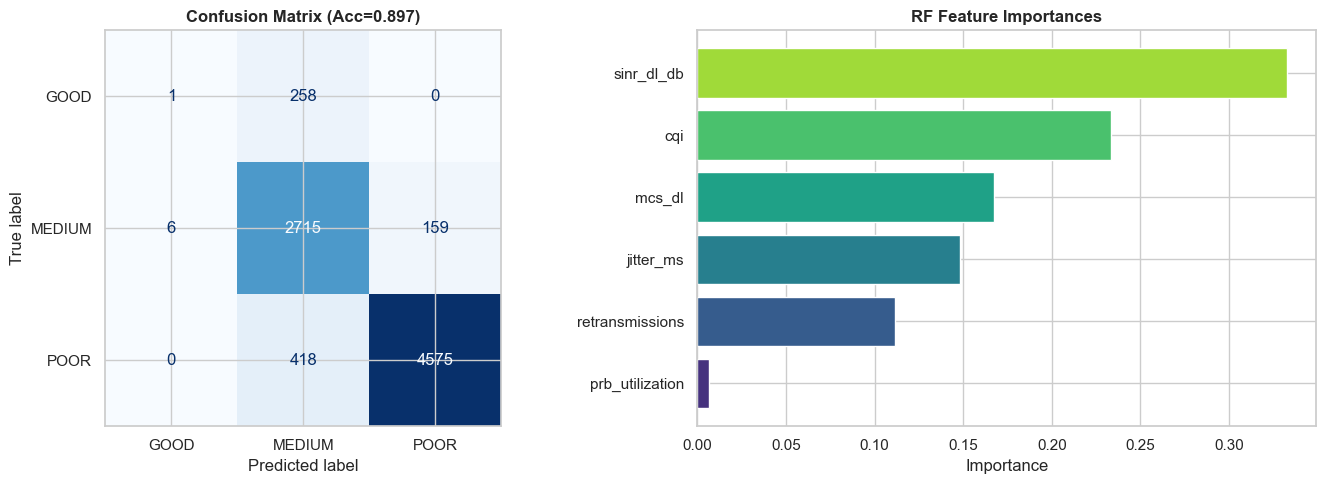

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Confusion matrix
labels = ["GOOD","MEDIUM","POOR"]
cm = confusion_matrix(y_te, y_pred, labels=labels)
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix (Acc={acc:.3f})", fontweight="bold")

# Feature importance
imp = importances.sort_values()
axes[1].barh([f.replace("norm_","") for f in imp.index], imp.values,
             color=sns.color_palette("viridis", len(imp)))
axes[1].set_title("RF Feature Importances", fontweight="bold")
axes[1].set_xlabel("Importance")
plt.tight_layout(); plt.show()

---
## Phase 6 — Category Benchmarking

In [12]:
def bench(df, col):
    g = df.groupby(col).agg(
        avg_qos=("qos_score","mean"), avg_thr=("throughput_mbps","mean"),
        avg_delay=("delay_ms","mean"), avg_pl=("packet_loss_ratio","mean"), n=("qos_score","count")
    ).reset_index()
    g["class"] = g["avg_qos"].apply(lambda s: "GOOD" if s>=0.65 else ("MEDIUM" if s>=0.35 else "POOR"))
    return g

lb = bench(df_c,"load_level");  mb = bench(df_c,"mobility_speed")
benchmark_df = pd.concat([
    lb.assign(category="load_level").rename(columns={"load_level":"val"}),
    mb.assign(category="mobility_speed").rename(columns={"mobility_speed":"val"})
], ignore_index=True)

print("By load_level:"); display(lb.round(4))
print("By mobility_speed:"); display(mb.round(4))

By load_level:


,load_level,avg_qos,avg_thr,avg_delay,avg_pl,n,class
0,1,0.5722,3.3012,123.9564,0.3376,12830,MEDIUM
1,2,0.5752,3.3897,116.4963,0.3539,12595,MEDIUM
2,3,0.5119,2.2083,162.9650,0.6254,3290,MEDIUM
3,4,0.3913,0.9444,227.5573,0.8798,2120,MEDIUM
4,5,0.3917,0.9882,190.7573,0.8994,1690,MEDIUM


By mobility_speed:


,mobility_speed,avg_qos,avg_thr,avg_delay,avg_pl,n,class
0,0,0.4960,2.2487,165.4980,0.5455,25640,MEDIUM
1,1,0.7235,5.4984,23.2825,0.0367,3295,GOOD
2,3,0.7312,5.6061,23.5327,0.0372,3295,GOOD
3,10,0.8455,5.8921,3.2613,0.0004,295,GOOD


---
## Phase 7 — Visualisations

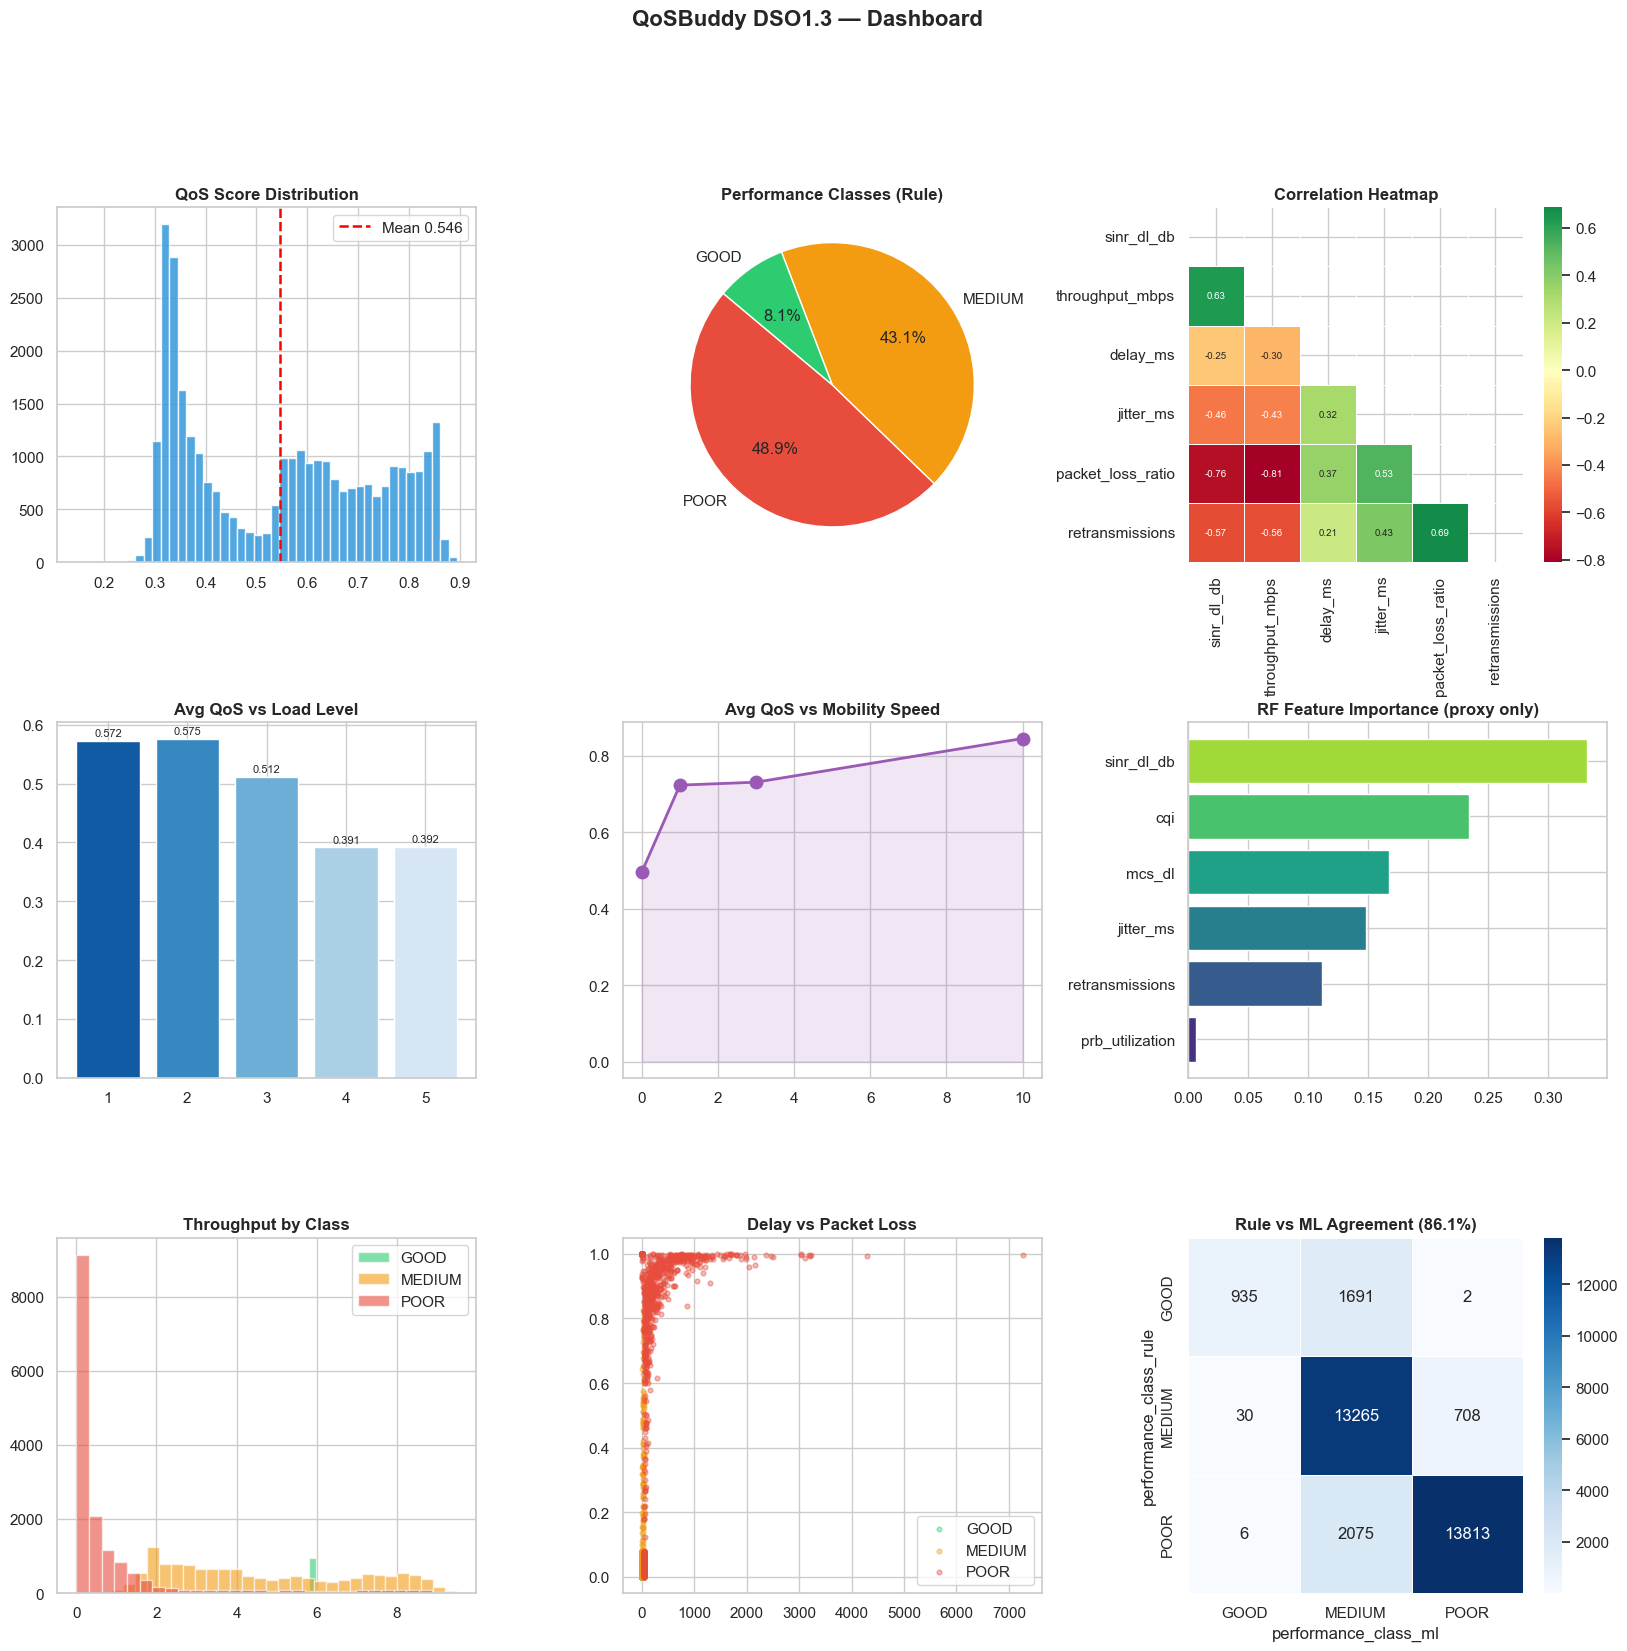

Dashboard saved ✅


In [13]:
fig = plt.figure(figsize=(20,18))
fig.suptitle("QoSBuddy DSO1.3 — Dashboard", fontsize=16, fontweight="bold", y=0.99)
gs = gridspec.GridSpec(3,3, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0,0])
ax1.hist(df_c["qos_score"], bins=45, color="#3498db", edgecolor="white", alpha=0.85)
ax1.axvline(df_c["qos_score"].mean(), color="red", linestyle="--", lw=1.8,
            label=f"Mean {df_c['qos_score'].mean():.3f}")
ax1.set_title("QoS Score Distribution", fontweight="bold"); ax1.legend()

ax2 = fig.add_subplot(gs[0,1])
cnt = df_c["performance_class_rule"].value_counts()
ax2.pie(cnt.values, labels=cnt.index, colors=[PALETTE[c] for c in cnt.index],
        autopct="%1.1f%%", startangle=140)
ax2.set_title("Performance Classes (Rule)", fontweight="bold")

ax3 = fig.add_subplot(gs[0,2])
corr_m = df_c[QOS_FEATURES].corr()
sns.heatmap(corr_m, mask=np.triu(np.ones_like(corr_m,dtype=bool)), ax=ax3,
            annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=0.5, annot_kws={"size":7})
ax3.set_title("Correlation Heatmap", fontweight="bold")

ax4 = fig.add_subplot(gs[1,0])
ld = df_c.groupby("load_level")["qos_score"].mean().reset_index()
b4 = ax4.bar(ld["load_level"].astype(str), ld["qos_score"],
             color=sns.color_palette("Blues_r",len(ld)), edgecolor="white")
ax4.bar_label(b4, fmt="%.3f", fontsize=8, padding=2)
ax4.set_title("Avg QoS vs Load Level", fontweight="bold")

ax5 = fig.add_subplot(gs[1,1])
mo = df_c.groupby("mobility_speed")["qos_score"].mean().reset_index()
ax5.plot(mo["mobility_speed"], mo["qos_score"], marker="o", color="#9b59b6", lw=2, ms=9)
ax5.fill_between(mo["mobility_speed"], mo["qos_score"], alpha=0.15, color="#9b59b6")
ax5.set_title("Avg QoS vs Mobility Speed", fontweight="bold")

ax6 = fig.add_subplot(gs[1,2])
imp_s = importances.sort_values()
ax6.barh([f.replace("norm_","") for f in imp_s.index], imp_s.values,
         color=sns.color_palette("viridis",len(imp_s)))
ax6.set_title("RF Feature Importance (proxy only)", fontweight="bold")

ax7 = fig.add_subplot(gs[2,0])
for cls, col in PALETTE.items():
    ax7.hist(df_c[df_c["performance_class_rule"]==cls]["throughput_mbps"],
             bins=30, alpha=0.6, label=cls, color=col, edgecolor="white")
ax7.set_title("Throughput by Class", fontweight="bold"); ax7.legend()

ax8 = fig.add_subplot(gs[2,1])
samp = df_c.sample(min(2500,len(df_c)), random_state=42)
for cls, col in PALETTE.items():
    s = samp[samp["performance_class_rule"]==cls]
    ax8.scatter(s["delay_ms"], s["packet_loss_ratio"], alpha=0.4, s=12, color=col, label=cls)
ax8.set_title("Delay vs Packet Loss", fontweight="bold"); ax8.legend()

ax9 = fig.add_subplot(gs[2,2])
rule_ml = pd.crosstab(df_c["performance_class_rule"], df_c["performance_class_ml"])
agreement = (df_c["performance_class_rule"]==df_c["performance_class_ml"]).mean()
sns.heatmap(rule_ml, ax=ax9, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
ax9.set_title(f"Rule vs ML Agreement ({agreement:.1%})", fontweight="bold")

plt.savefig(f"{OUTPUT_DIR}/qos_dashboard.png", dpi=130, bbox_inches="tight", facecolor="white")
plt.show(); print("Dashboard saved ✅")

---
## Phase 8 — Insights

In [14]:
cp = df_c["performance_class_rule"].value_counts(normalize=True)*100
print(f"Class distribution — POOR: {cp.get('POOR',0):.1f}%  MEDIUM: {cp.get('MEDIUM',0):.1f}%  GOOD: {cp.get('GOOD',0):.1f}%")
print(f"Worst load level:  {df_c.groupby('load_level')['qos_score'].mean().idxmin()}")
print(f"SINR ↔ Throughput: {df_c['sinr_dl_db'].corr(df_c['throughput_mbps']):.4f}  ← root cause")
print(f"Delay ↔ PktLoss:   {df_c['delay_ms'].corr(df_c['packet_loss_ratio']):.4f}")
print(f"Mobility ↔ QoS:    {df_c['mobility_speed'].corr(df_c['qos_score']):.4f}")

Class distribution — POOR: 48.9%  MEDIUM: 43.1%  GOOD: 8.1%
Worst load level:  4
SINR ↔ Throughput: 0.6347  ← root cause
Delay ↔ PktLoss:   0.3653
Mobility ↔ QoS:    0.4169


---
## Phase 9 — Export

In [15]:
export_cols = [c for c in df_c.columns if not c.startswith("norm_")]
df_c[export_cols].to_csv(f"{OUTPUT_DIR}/dataset_with_qos_scores.csv", index=False)
benchmark_df.to_csv(f"{OUTPUT_DIR}/benchmark_report_by_category.csv", index=False)
print("Exported dataset_with_qos_scores.csv ✅")
print("Exported benchmark_report_by_category.csv ✅")

Exported dataset_with_qos_scores.csv ✅
Exported benchmark_report_by_category.csv ✅


---
## Phase 10 — SHAP Explainability

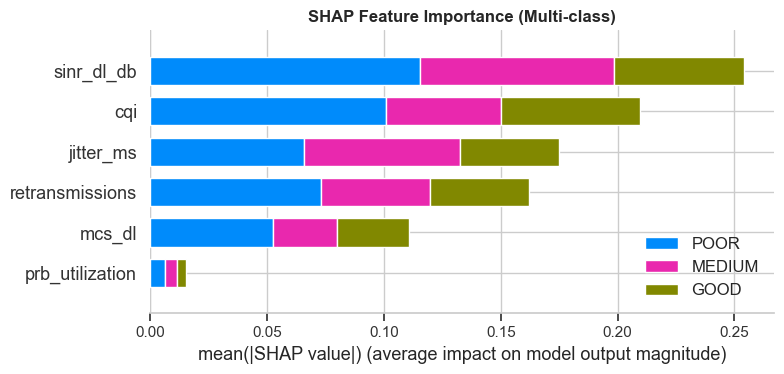

SHAP ✅
── Final Model Summary ──────────────────────────────────
Dataset rows   : 32,525
ML features    : ['norm_sinr_dl_db', 'norm_jitter_ms', 'norm_retransmissions', 'norm_prb_utilization', 'norm_cqi', 'norm_mcs_dl']
Split method   : Temporal (75% train / 25% test by timestamp)
Hold-out Acc   : 0.8966  ← realistic, not 100%
Weighted F1    : 0.8845
Macro F1       : 0.6047
5-Fold CV F1   : 0.8229
✅ DSO1.3 Complete


In [16]:
try:
    import shap
    explainer  = shap.TreeExplainer(rf)
    X_sample   = X_tr.sample(min(500,len(X_tr)), random_state=42)
    shap_vals  = explainer.shap_values(X_sample)
    feat_names = [f.replace("norm_","") for f in feat_cols]
    plt.figure(figsize=(10,5))
    shap.summary_plot(shap_vals, X_sample, feature_names=feat_names,
                      class_names=["GOOD","MEDIUM","POOR"], plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Multi-class)", fontweight="bold")
    plt.tight_layout(); plt.show(); print("SHAP ✅")
except ImportError:
    print("pip install shap to enable SHAP explainability")

# Final summary
print(f"── Final Model Summary ──────────────────────────────────")
print(f"Dataset rows   : {len(df_c):,}")
print(f"ML features    : {feat_cols}")
print(f"Split method   : Temporal (75% train / 25% test by timestamp)")
print(f"Hold-out Acc   : {acc:.4f}  ← realistic, not 100%")
print(f"Weighted F1    : {f1w:.4f}")
print(f"Macro F1       : {f1m:.4f}")
print(f"5-Fold CV F1   : {cv5:.4f}")
print("✅ DSO1.3 Complete")